# Customer Transactions Data Analysis

**Author:** Aylin Nakhostin

## Project Overview

This project performs exploratory data analysis (EDA), preprocessing, and validation on a customer transactions dataset using Python. The goal is to clean the data, understand customer behavior, identify data quality issues, and prepare the dataset for further analysis or machine learning applications.

# 1. Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load and Explore the Dataset

In [2]:
data = pd.read_csv("project1_df.csv")

In [3]:
data.head()

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,Delhi
3,180333,1395204173,Other,60 and above,04/11/2020 04:41:57,Sports & Fitness,No,NaN,0.00,5695.612650,5695.612650,Debit Card,Delhi
4,447553,8009390577,Male,18-25,31/05/2022 17:00:32,Sports & Fitness,Yes,WELCOME5,439.92,2292.651500,1852.731500,Credit Card,Delhi


## About The Dataset:

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  object 
 3   Age Group              55000 non-null  object 
 4   Purchase Date          55000 non-null  object 
 5   Product Category       55000 non-null  object 
 6   Discount Availed       55000 non-null  object 
 7   Discount Name          27415 non-null  object 
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  object 
 12  Location               55000 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 5.5+ MB


**The Dataset has 13 columns and 55,000 rows <br>**

**Rows:** <br>
-  Entries of customer transactions from a chain store

**Columns :** <br>
-  **CID (Customer ID):** <br> A unique identifier for each customer.<br>
-  **TID (Transaction ID):** <br> A unique identifier for each transaction.<br>
-  **Gender:** <br> The gender of the customer, categorized as Male or Female or Other.<br>
-  **Age Group:** <br> Age group of the customer, divided into several ranges.<br>
-  **Purchase Date:** <br> The timestamp of when the transaction took place.<br>
-  **Product Category:** <br> The category of the product purchased, such as Electronics, Apparel, etc.<br>
-  **Discount Availed:** <br> Indicates whether the customer availed any discount (Yes/No).<br>
-  **Discount Name:** <br> Name of the discount applied (e.g., FESTIVE50).<br>
-  **Discount Amount (INR):** <br> The amount of discount availed by the customer.<br>
-  **Gross Amount:** <br> The total amount before applying any discount.<br>
-  **Net Amount:** <br> The final amount after applying the discount.<br>
-  **Purchase Method:** <br> The payment method used (e.g., Credit Card, Debit Card, etc.).<br>
-  **Location:** <br> The city where the purchase took place.<br>

In [5]:
data.describe()

,CID,TID,Discount Amount (INR),Gross Amount,Net Amount
count,55000.000000,5.500000e+04,55000.000000,55000.000000,55000.000000
mean,551245.593891,5.504740e+09,136.986796,3012.936606,2875.949810
std,260603.330337,2.594534e+09,165.375502,1718.431066,1726.127778
min,100009.000000,1.000163e+09,0.000000,136.454325,-351.119775
25%,323717.000000,3.252604e+09,0.000000,1562.111325,1429.551863
50%,550088.500000,5.498383e+09,0.000000,2954.266150,2814.910875
75%,776955.750000,7.747933e+09,274.115000,4342.221675,4211.407838
max,999996.000000,9.999393e+09,500.000000,8394.825600,8394.825600


# 3. Data Preprocessing

## Convert 'Purchase Date' to datetime format

In [6]:
data['Purchase Date'] = pd.to_datetime(data['Purchase Date'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
print(data['Purchase Date'].dtype)

datetime64[ns]


## Handling Missing Values and Duplicates

In [7]:
# Check for missing values
missing_values = data.isnull().sum()
print("missing_values: \n",missing_values,)

missing_values: 
 CID                          0
TID                          0
Gender                       0
Age Group                    0
Purchase Date                0
Product Category             0
Discount Availed             0
Discount Name            27585
Discount Amount (INR)        0
Gross Amount                 0
Net Amount                   0
Purchase Method              0
Location                     0
dtype: int64


Only the Discount Name column contains missing values, which will be handled during the data preprocessing stage.

In [8]:
# Fill missing discount names with "No Discount"
data.fillna({"Discount Name" : 'No Discount'}, inplace=True)

print("Discount Name:\n", data["Discount Name"])

Discount Name:
 0              FESTIVE50
1        SEASONALOFFER21
2        SEASONALOFFER21
3            No Discount
4               WELCOME5
              ...       
54995    SEASONALOFFER21
54996    SEASONALOFFER21
54997           NEWYEARS
54998    SEASONALOFFER21
54999           NEWYEARS
Name: Discount Name, Length: 55000, dtype: object


In [9]:
# Check for exact duplicate rows
duplicates = data.duplicated()
print("duplicated rows: \n", data[duplicates])

duplicated rows: 
 Empty DataFrame
Columns: [CID, TID, Gender, Age Group, Purchase Date, Product Category, Discount Availed, Discount Name, Discount Amount (INR), Gross Amount, Net Amount, Purchase Method, Location]
Index: []


there are no duplicated rows

# 4. Data Validation

## Checking for Negative or Zero Values

In [10]:
negative_or_zero_values = data[(data['Gross Amount'] <= 0)]
print(f"Number of Gross Amount with negative or zero values: {len(negative_or_zero_values)}")

Number of Gross Amount with negative or zero values: 0


## Checking for Future Dates in 'Purchase Date'

In [11]:
# Get the current date
current_date = pd.Timestamp.now()

# Find rows where the 'Purchase Date' is in the future
future_purchase_dates = data[data['Purchase Date'] > current_date]

# Print the rows with future purchase dates
print(f"Number of rows with future purchase dates: {len(future_purchase_dates)}")

Number of rows with future purchase dates: 0


# 5. Feature Engineering

## Adding a 'Purchase Season' Column

In [12]:
# Function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Apply the function to create a new column
data['Purchase Season'] = data['Purchase Date'].dt.month.apply(get_season)

print("Purchase Season: \n", data['Purchase Season'])

Purchase Season: 
 0        Summer
1        Winter
2        Spring
3          Fall
4        Spring
          ...  
54995    Winter
54996    Summer
54997    Summer
54998    Summer
54999    Summer
Name: Purchase Season, Length: 55000, dtype: object


## Standardizing Data Types

In [13]:
columns_to_convert = ['Gender', 'Age Group', 'Location', 'Purchase Method', 'Product Category', 'Purchase Season']
data[columns_to_convert] = data[columns_to_convert].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CID                    55000 non-null  int64         
 1   TID                    55000 non-null  int64         
 2   Gender                 55000 non-null  category      
 3   Age Group              55000 non-null  category      
 4   Purchase Date          55000 non-null  datetime64[ns]
 5   Product Category       55000 non-null  category      
 6   Discount Availed       55000 non-null  object        
 7   Discount Name          55000 non-null  object        
 8   Discount Amount (INR)  55000 non-null  float64       
 9   Gross Amount           55000 non-null  float64       
 10  Net Amount             55000 non-null  float64       
 11  Purchase Method        55000 non-null  category      
 12  Location               55000 non-null  category      
 13  P

A noticeable reduction in memory usage is observed, decreasing from over 5.5 MB to approximately 3.7 MB.

# 6. Outlier Detection

## Gross Amount and Net Amount outliers

Gross Amount
median:  2954.2661500000004
mean:  3012.936605973182
std_dev:  1718.4310656418672


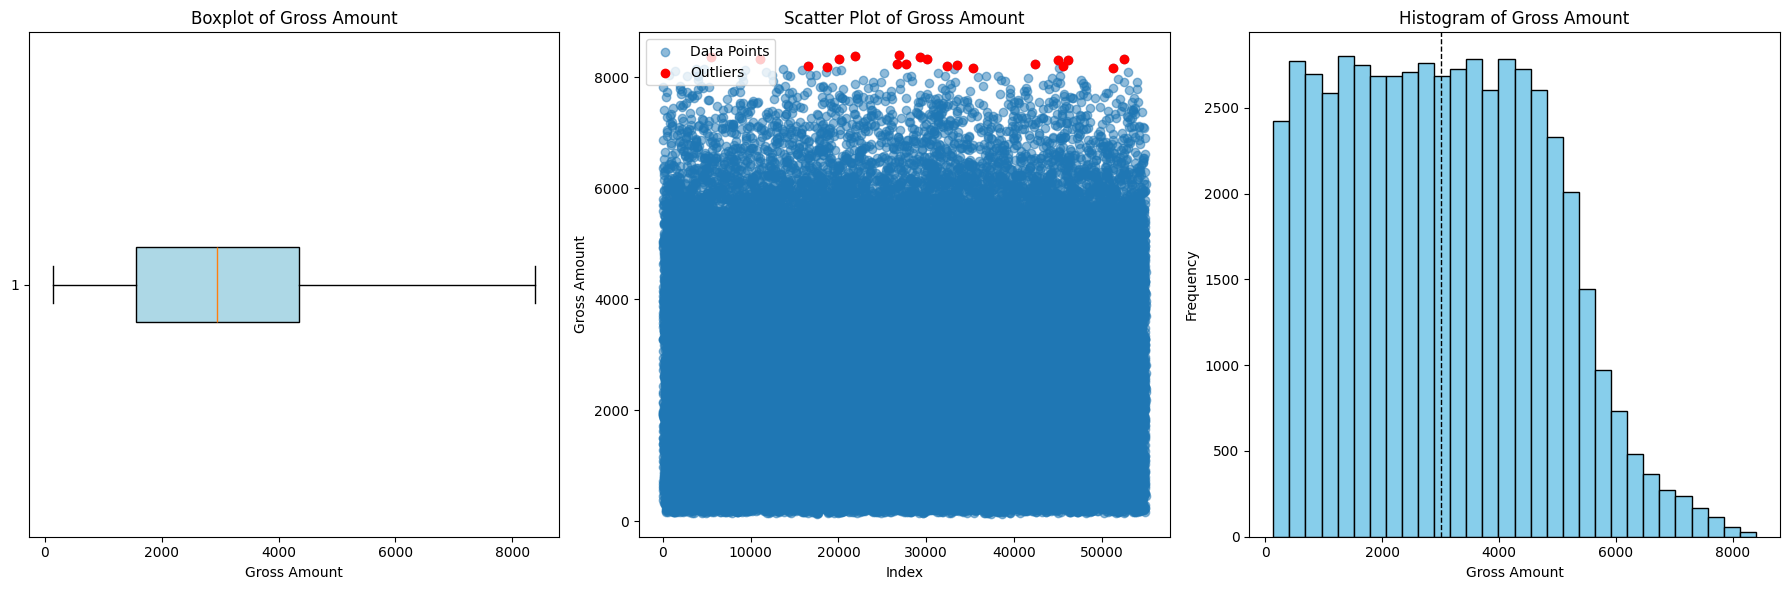

Net Amount
median:  2814.910875
mean:  2875.949810155
std_dev:  1726.1277780398761


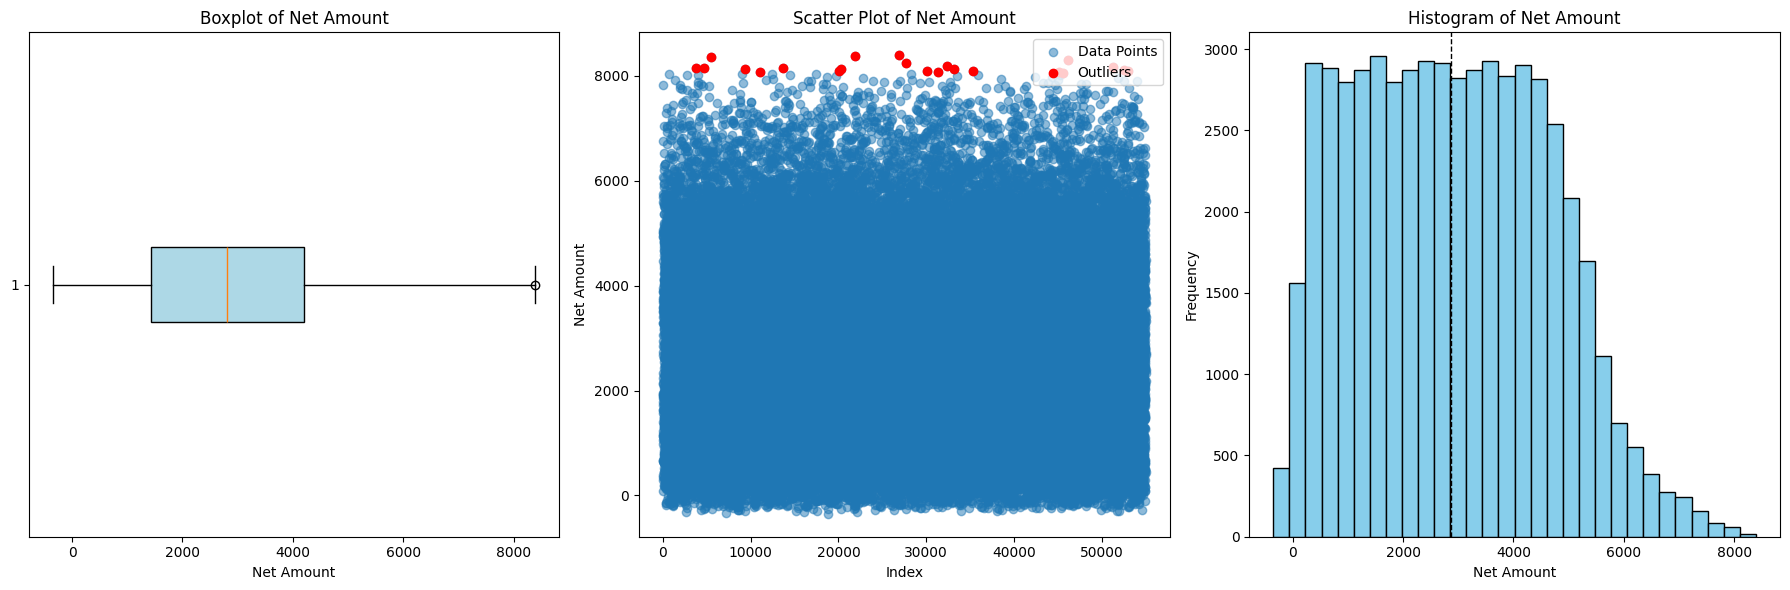

is_outlier
False    54978
True        22
Name: count, dtype: int64


In [14]:
# List of columns you want to check for outliers
columns_to_check = ['Gross Amount', 'Net Amount']

# Loop through each column and generate plots for each column's outliers
for column in columns_to_check:
    mean = data[column].mean()
    std_dev = data[column].std()
    median = data[column].median()

    print(column)
    print("median: ", median)
    print("mean: ", mean)
    print("std_dev: ", std_dev)
    
    # Define outliers
    outliers = data[(data[column] > mean + 3 * std_dev) | (data[column] < mean - 3 * std_dev)]

    # Create subplots with 1 row and 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # Step 2.1: Boxplot
    axs[0].boxplot(data[column], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
    axs[0].set_title(f'Boxplot of {column}')
    axs[0].set_xlabel(column)

    # Step 2.2: Scatter Plot
    axs[1].scatter(data.index, data[column], alpha=0.5, label='Data Points')
    axs[1].scatter(outliers.index, outliers[column], color='red', label='Outliers')
    axs[1].set_title(f'Scatter Plot of {column}')
    axs[1].set_xlabel('Index')
    axs[1].set_ylabel(column)
    axs[1].legend()

    # Step 2.3: Histogram
    axs[2].hist(data[column], bins=30, color='skyblue', edgecolor='black')
    axs[2].axvline(mean, color='k', linestyle='dashed', linewidth=1 , label='Mean')
    axs[2].set_title(f'Histogram of {column}')
    axs[2].set_xlabel(column)
    axs[2].set_ylabel('Frequency')

    # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.show()

    # Flag outliers with a new column
    data['is_outlier'] = np.where((data[column] > mean + 3 * std_dev) | (data[column] < mean - 3 * std_dev), True, False)

# Print outlier counts
print(data['is_outlier'].value_counts())

The red data points represent the identified outliers, which have been flagged in the dataset.</br>
Both histograms exhibit a right-skewed distribution.

# 7. Handling Inconsistent Customer Data

## Customers with More Than Usual Locations

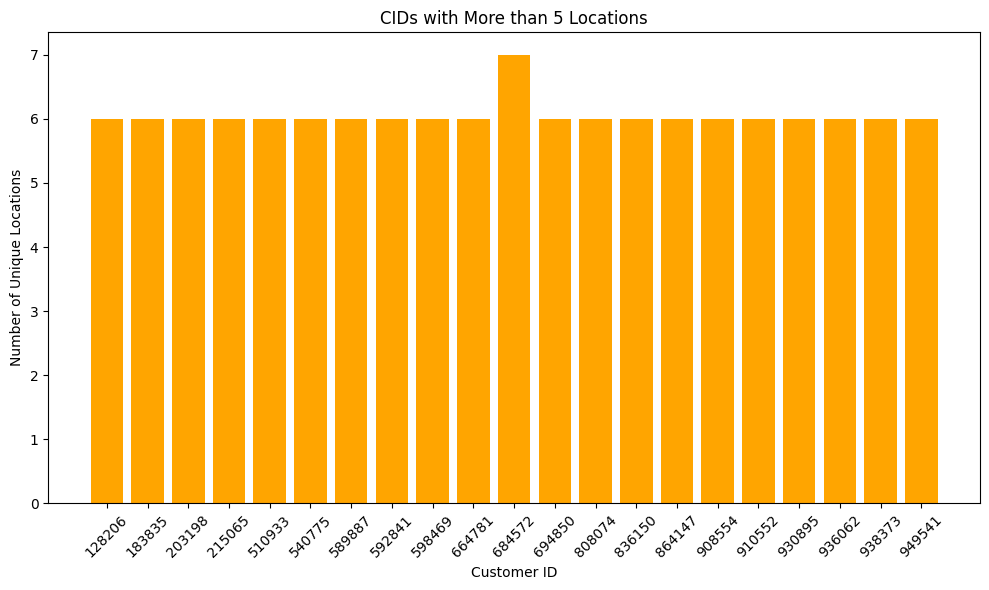

is_outlier
False    54858
True       142
Name: count, dtype: int64


In [15]:
# Check if the same CID has different locations
inconsistent_cid_location = data.groupby('CID')['Location'].nunique().reset_index()
inconsistent_cid_location = inconsistent_cid_location[inconsistent_cid_location['Location'] > 5]

#Plot the CIDs with more than 5 locations
plt.figure(figsize=(10, 6))
plt.bar(inconsistent_cid_location['CID'].astype(str), inconsistent_cid_location['Location'], color='orange')
plt.title('CIDs with More than 5 Locations')
plt.xlabel('Customer ID')
plt.ylabel('Number of Unique Locations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mark CIDs with more than 6 locations as outliers (True)
data['is_outlier'] = data['CID'].isin(inconsistent_cid_location['CID'])

# Print outlier counts
print(data['is_outlier'].value_counts())

Customers with purchases from more than five different locations are identified, as this may indicate data inconsistencies or potential fraud. These customers are visualized and flagged as outliers.

## Resolving Conflicting Age Groups and Genders for CIDs

In [16]:
# Identify CIDs with conflicting age groups or genders
duplicate_cid = data.groupby('CID').agg({
    'Age Group': pd.Series.nunique,
    'Gender': pd.Series.nunique
}).reset_index()

# Filter CIDs with more than one unique age group or gender
conflicting_cid = duplicate_cid[(duplicate_cid['Age Group'] > 1) | (duplicate_cid['Gender'] > 1)]
print("Customers with conflicting Age Groups or Genders:")
print(conflicting_cid)

# Resolve conflicts by choosing the most frequent age group and gender for each CID
resolved_age_gender = data.groupby('CID').agg({
    'Age Group': lambda x: x.mode()[0],
    'Gender': lambda x: x.mode()[0]
}).reset_index()

# Merge the resolved data back into the original dataset
data = pd.merge(data.drop(columns=['Age Group', 'Gender']), resolved_age_gender, on='CID', how='left')


Customers with conflicting Age Groups or Genders:
          CID  Age Group  Gender
3      100089          3       3
5      100097          2       2
8      100193          2       2
9      100205          3       2
10     100258          2       1
...       ...        ...     ...
29054  999529          1       3
29058  999601          2       3
29059  999636          2       1
29067  999883          2       2
29070  999996          2       2

[15085 rows x 3 columns]


Customers with inconsistent demographic information are identified, and these inconsistencies are resolved by assigning the most frequently occurring age group and gender for each customer.

# 8. Exploratory Data Analysis

## PairPlot

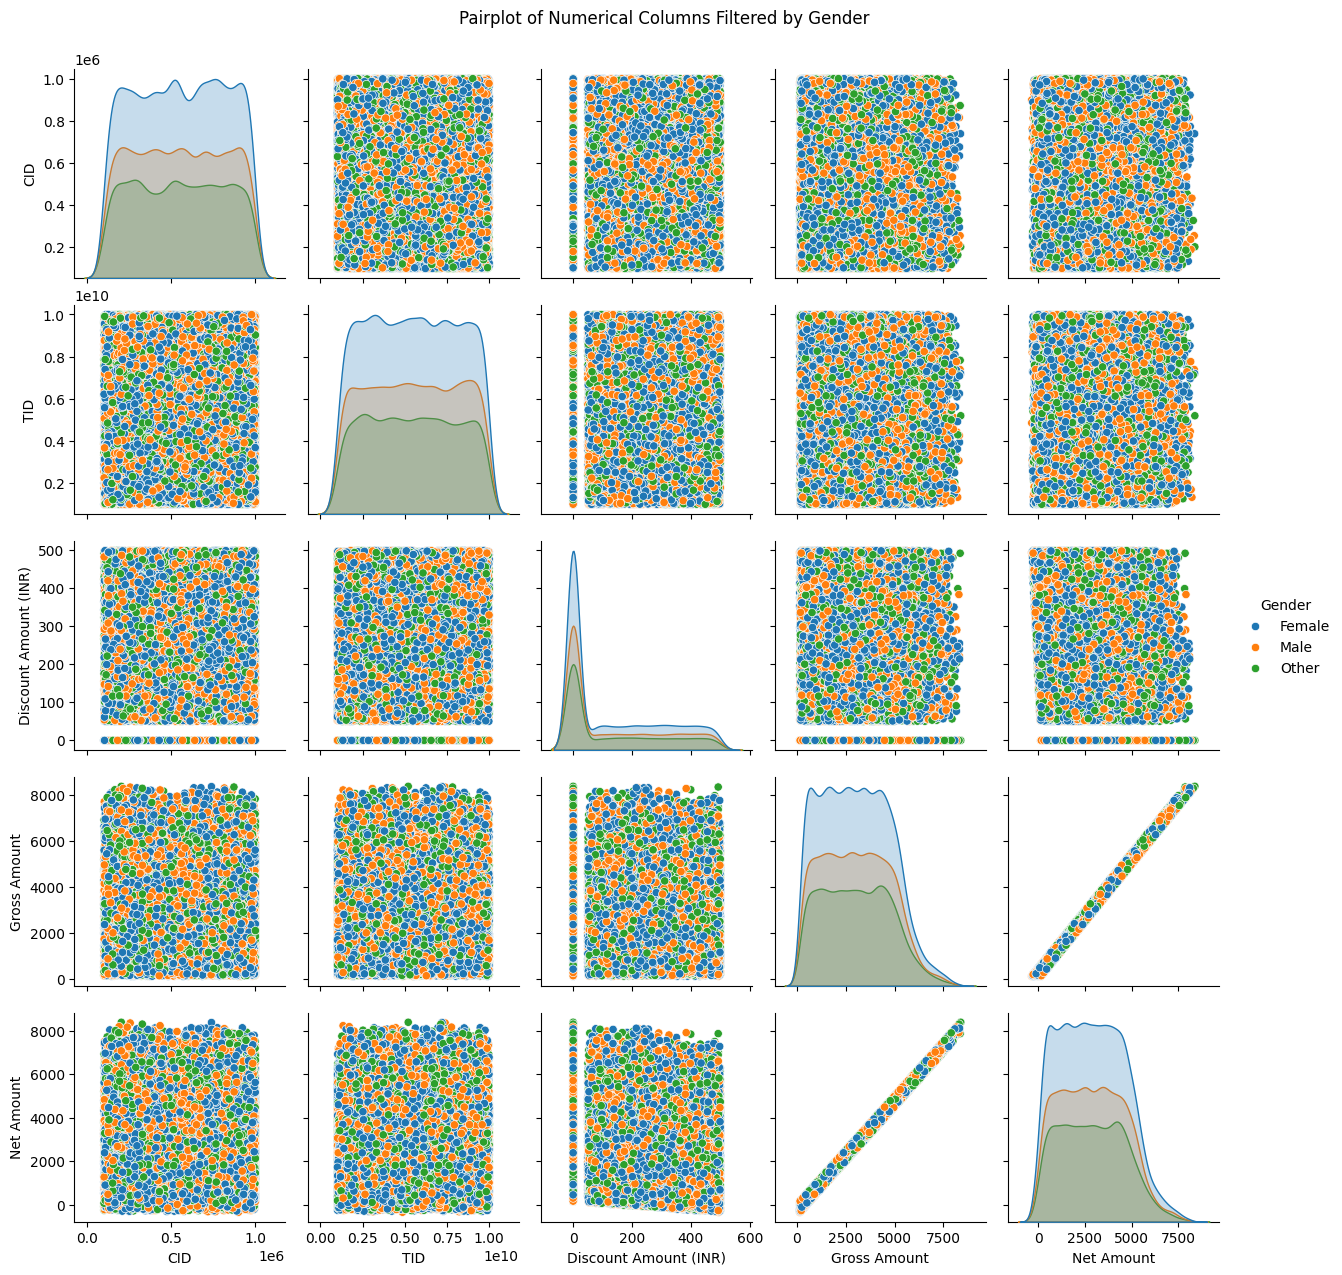

In [17]:
# Select only numerical columns along with the 'Gender' column
numerical_columns_with_gender = data[['Gender'] + list(data.select_dtypes(include=['float64', 'int64']).columns)]

# Create a pairplot with 'Gender' as the hue
sns.pairplot(numerical_columns_with_gender, hue='Gender', diag_kind='kde')  # hue for color based on gender
plt.suptitle('Pairplot of Numerical Columns Filtered by Gender', y=1.02)
plt.show()

Distribution of Gross Amount and Net Amount:

-  Both Gross Amount and Net Amount show a fairly even distribution, with no significant outliers.
-  As expected, Net Amount correlates perfectly with Gross Amount due to the close relationship between these two variables (i.e., Net Amount = Gross Amount - Discount).

No Visible Patterns by Gender:

-  The scatter plots show that there is no distinct pattern in the relationships between variables when grouped by Gender (Female, Male, Other). The data points are distributed evenly across all genders.


## HeatMap

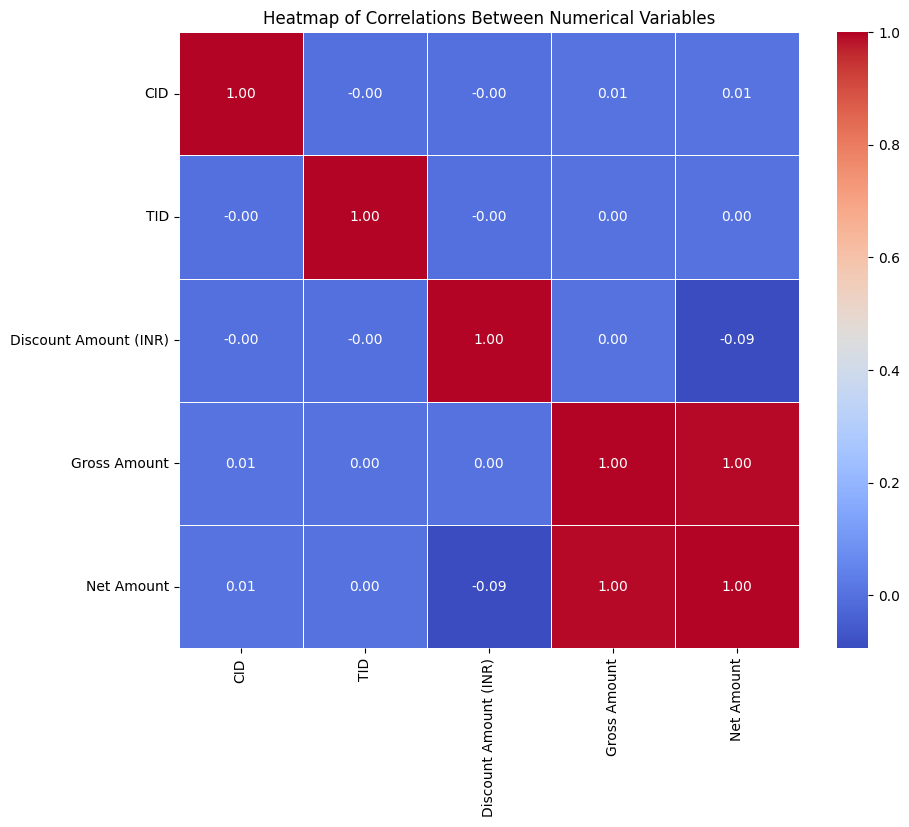

In [18]:
# Select only numerical columns from the dataset
numerical_columns = data.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix for the numerical columns
corr_matrix = numerical_columns.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Heatmap of Correlations Between Numerical Variables')
plt.show()

Strong Correlation Between Gross and Net Amount:

There is a perfect positive correlation between Gross Amount and Net Amount (correlation coefficient = 1.00). This is expected since the net amount is derived directly from the gross amount, possibly after applying discounts.

Weak to No Correlation with Other Variables:

# 9. Visualizations By Age Group and Gender

## Average Gross and Net and Discount Amount and Transaction Count by Location

In [19]:
# Recalculate the age_gender_group after resolving inconsistencies and include 'Discount Amount (INR)'
age_gender_group = data.groupby(['Gender', 'Age Group'], observed=False).agg({
    'Gross Amount': 'mean',
    'Net Amount': 'mean',
    'Discount Amount (INR)': 'mean',  # Add Discount Amount (INR)
    'TID': 'count'  # Transaction count
}).reset_index()

age_gender_group.rename(columns={'TID': 'Transaction Count'}, inplace=True)


# Prepare data for plotting
bar_width = 0.35
age_groups = age_gender_group['Age Group'].unique()
index = np.arange(len(age_groups))

# Separate data by gender
female_data = age_gender_group[age_gender_group['Gender'] == 'Female']
male_data = age_gender_group[age_gender_group['Gender'] == 'Male']


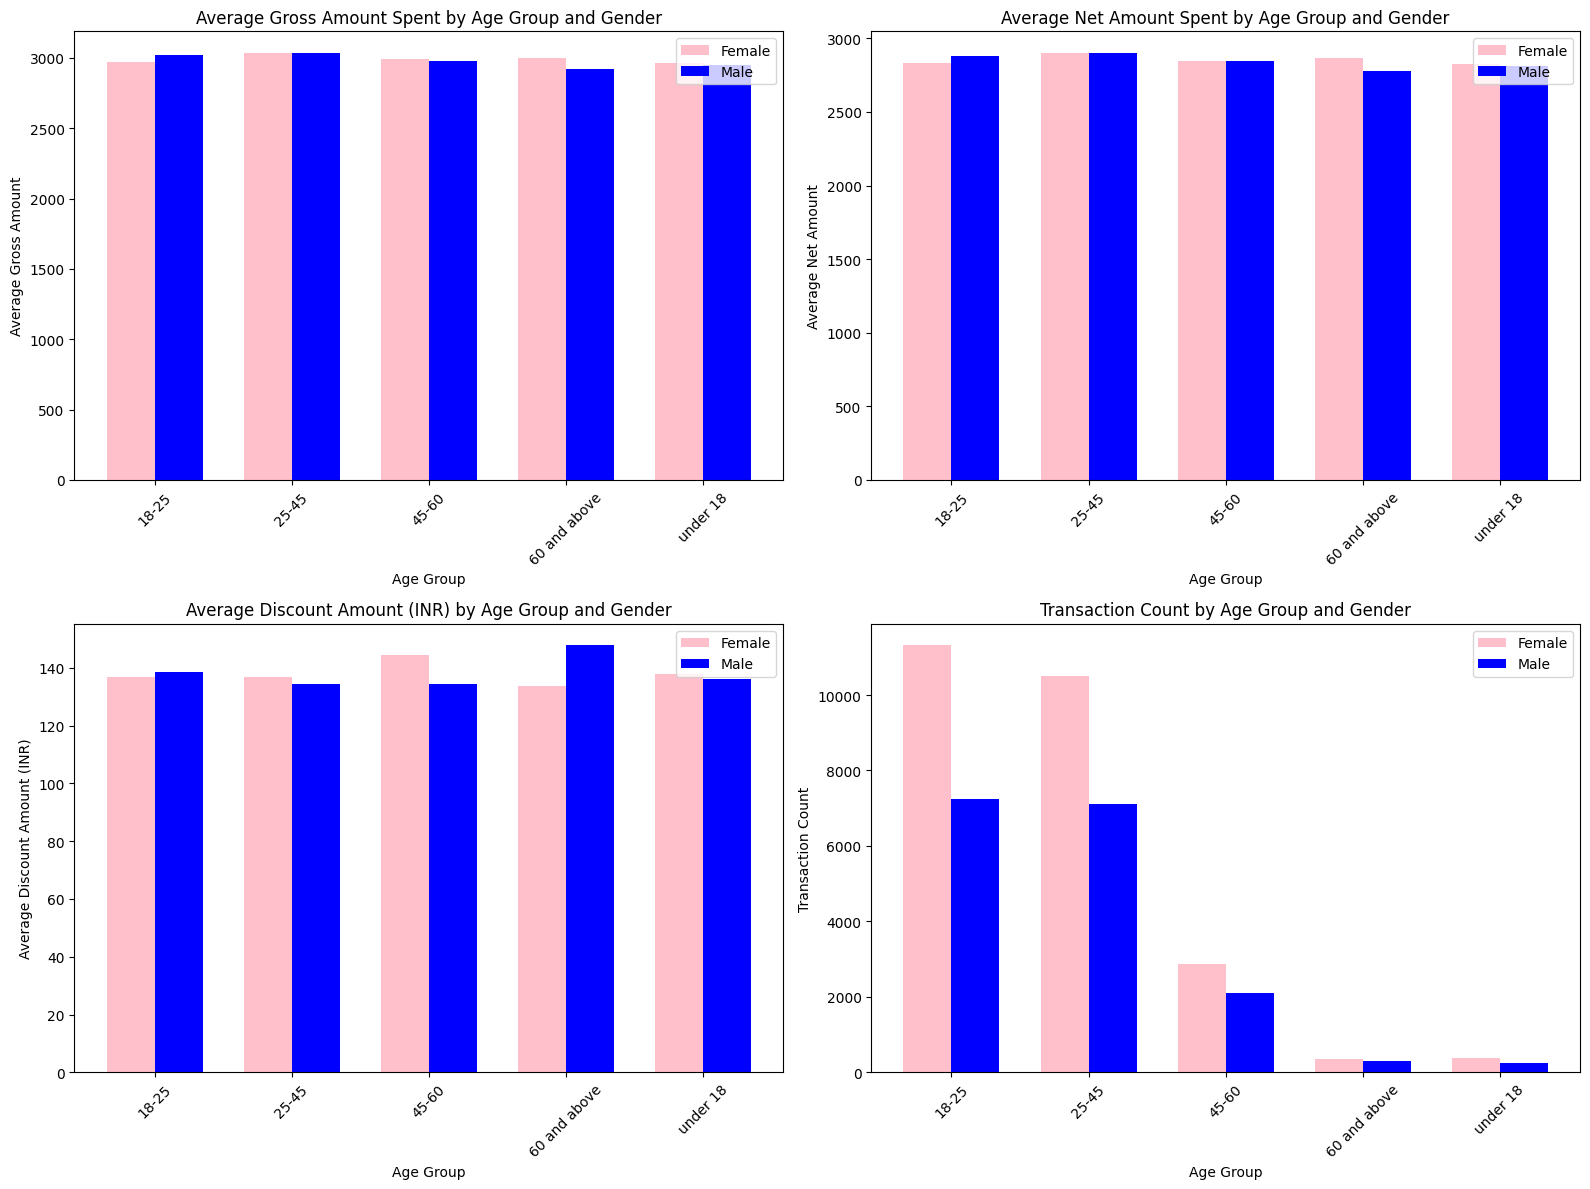

In [20]:
# Create a 2x2 grid of subplots for the four charts
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Adjust bar width
bar_width = 0.35

# Plot Average Gross Amount (Top-left)
axs[0, 0].bar(index - bar_width/2, female_data['Gross Amount'], bar_width, label='Female', color='pink')
axs[0, 0].bar(index + bar_width/2, male_data['Gross Amount'], bar_width, label='Male', color='blue')
axs[0, 0].set_xlabel('Age Group')
axs[0, 0].set_ylabel('Average Gross Amount')
axs[0, 0].set_title('Average Gross Amount Spent by Age Group and Gender')
axs[0, 0].set_xticks(index)
axs[0, 0].set_xticklabels(age_groups)
axs[0, 0].legend()
axs[0, 0].tick_params(axis='x', rotation=45)

# Plot Average Net Amount (Top-right)
axs[0, 1].bar(index - bar_width/2, female_data['Net Amount'], bar_width, label='Female', color='pink')
axs[0, 1].bar(index + bar_width/2, male_data['Net Amount'], bar_width, label='Male', color='blue')
axs[0, 1].set_xlabel('Age Group')
axs[0, 1].set_ylabel('Average Net Amount')
axs[0, 1].set_title('Average Net Amount Spent by Age Group and Gender')
axs[0, 1].set_xticks(index)
axs[0, 1].set_xticklabels(age_groups)
axs[0, 1].legend()
axs[0, 1].tick_params(axis='x', rotation=45)

# Plot Average Discount Amount (INR) (Bottom-left)
axs[1, 0].bar(index - bar_width/2, female_data['Discount Amount (INR)'], bar_width, label='Female', color='pink')
axs[1, 0].bar(index + bar_width/2, male_data['Discount Amount (INR)'], bar_width, label='Male', color='blue')
axs[1, 0].set_xlabel('Age Group')
axs[1, 0].set_ylabel('Average Discount Amount (INR)')
axs[1, 0].set_title('Average Discount Amount (INR) by Age Group and Gender')
axs[1, 0].set_xticks(index)
axs[1, 0].set_xticklabels(age_groups)
axs[1, 0].legend()
axs[1, 0].tick_params(axis='x', rotation=45)

# Plot Transaction Count (Bottom-right)
axs[1, 1].bar(index - bar_width/2, female_data['Transaction Count'], bar_width, label='Female', color='pink')
axs[1, 1].bar(index + bar_width/2, male_data['Transaction Count'], bar_width, label='Male', color='blue')
axs[1, 1].set_xlabel('Age Group')
axs[1, 1].set_ylabel('Transaction Count')
axs[1, 1].set_title('Transaction Count by Age Group and Gender')
axs[1, 1].set_xticks(index)
axs[1, 1].set_xticklabels(age_groups)
axs[1, 1].legend()
axs[1, 1].tick_params(axis='x', rotation=45)

# Adjust the layout
plt.tight_layout()
plt.show()


-  The average gross amount spent by different age groups and genders, is almost the same
-  The average net amount spent after discounts, segmented by age group and gender is also almost the same
-  The average discount amount held by different age groups and genders shows that men above 60 yearsold have the most discount amount and after them there are women 45-60 years old
-  The number of transactions made by each age group and gender, indicating customer engagement levels, shows that women have higher transaction in comparison to men (about 1,681 more!) and also 18-45 years old women have the most transactions

In [21]:
# Calculate the mean for needed metrics (Discount Amount, and Transaction Count) by gender and age group

mean_discount_female = female_data['Discount Amount (INR)'].mean()
mean_discount_male = male_data['Discount Amount (INR)'].mean()

mean_transaction_female = female_data['Transaction Count'].mean()
mean_transaction_male = male_data['Transaction Count'].mean()

# Display the results
print(
    "mean_discount_female", mean_discount_female, "\n",
    "mean_discount_male", mean_discount_male, "\n",
    "mean_transaction_female", mean_transaction_female, "\n",
    "mean_transaction_male", mean_transaction_male, "\n"
)

mean_discount_female 137.8220569377809 
 mean_discount_male 138.16914863272478 
 mean_transaction_female 5088.6 
 mean_transaction_male 3407.4 



## Product Category Preferences by Age and Gender

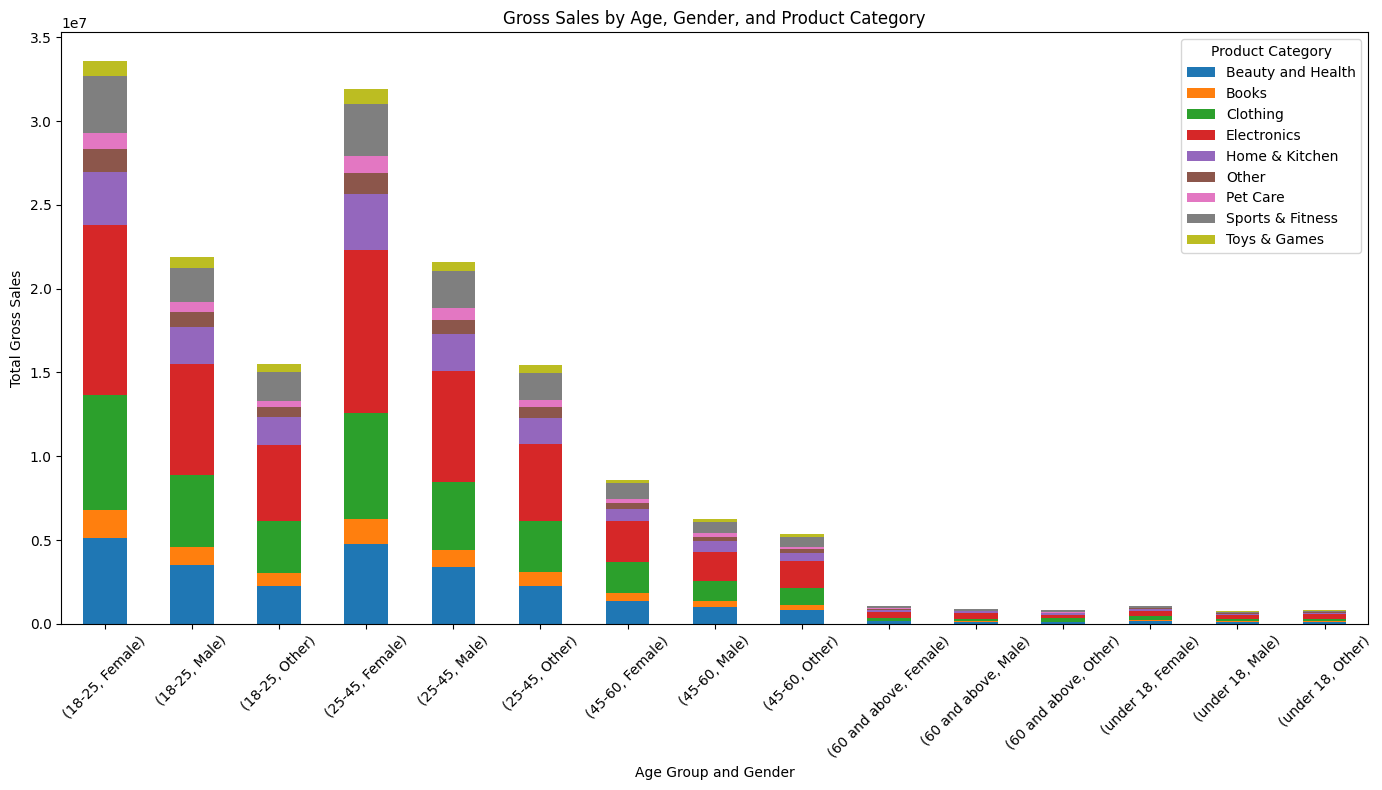

In [22]:
# Step 1: Group by Age Group, Gender, and Product Category to calculate total gross sales
age_gender_category_sales = data.groupby(['Age Group', 'Gender', 'Product Category'], observed=True).agg({
    'Gross Amount': 'sum'
}).reset_index()

# Step 2: Pivot the table to make it easier to visualize
pivot_age_gender_category = age_gender_category_sales.pivot_table(index=['Age Group', 'Gender'], columns='Product Category', values='Gross Amount', fill_value=0, observed=True)

# Step 3: Plot a stacked bar chart for age, gender, and product category preferences
pivot_age_gender_category.plot(kind='bar', stacked=True, figsize=(14, 8))

# Set labels and title
plt.xlabel('Age Group and Gender')
plt.ylabel('Total Gross Sales')
plt.title('Gross Sales by Age, Gender, and Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

-  The (18-25, Female) and (18-25, Male) groups have the highest total gross sales, followed by (25-45, Female) and (25-45, Male).
-  Older age groups, such as (60 and above) and (45-60), have notably lower gross sales compared to younger demographics.
-  Clothing (represented in red) contributes a large portion of sales across most demographic groups, particularly in the 18-25 and 25-45 age ranges.
-  Electronics (green) is another significant contributor to gross sales, particularly among males in the younger age groups.
-  Beauty and Health (blue) seems to dominate in the Female demographic groups, especially those aged 18-25 and 25-45.
-  Categories like Books (orange) and Toys & Games (yellow) contribute much smaller portions to total sales across all demographic groups.

# 10. Sales Analysis by Location

## Average Gross and Net and Discount Amount by Location

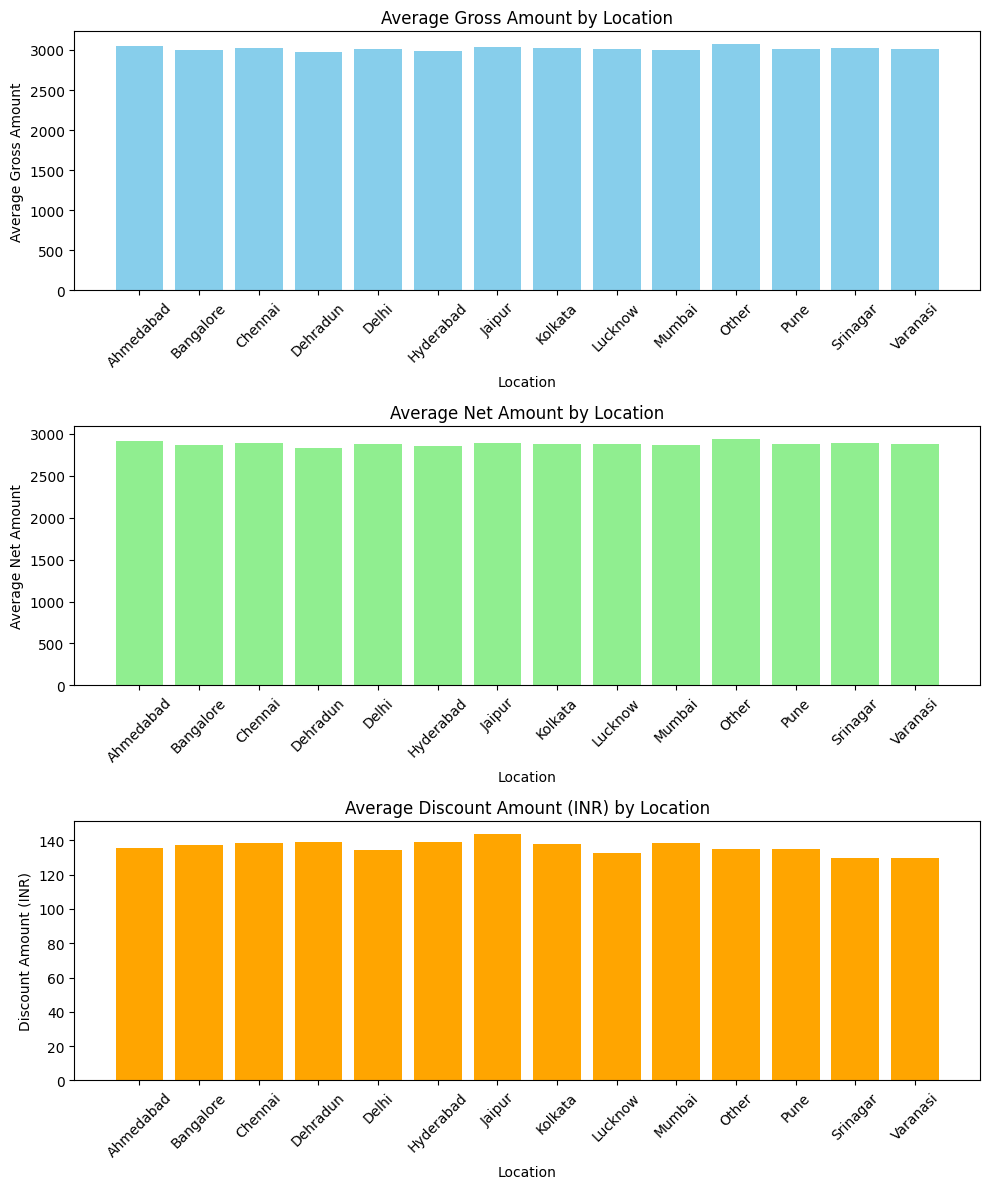

In [23]:
# Group by Location to calculate averages
location_sales_group = data.groupby('Location', observed=True).agg({
    'Gross Amount': 'mean',
    'Net Amount': 'mean',
    'Discount Amount (INR)': 'mean',  # Add Discount Amount (INR)
}).reset_index()

# Plotting the average amounts and discounts availed
fig, ax = plt.subplots(3, 1, figsize=(10, 12))

# Average Gross Amount
ax[0].bar(location_sales_group['Location'], location_sales_group['Gross Amount'], color='skyblue')
ax[0].set_xlabel('Location')
ax[0].set_ylabel('Average Gross Amount')
ax[0].set_title('Average Gross Amount by Location')
ax[0].tick_params(axis='x', rotation=45)

# Average Net Amount
ax[1].bar(location_sales_group['Location'], location_sales_group['Net Amount'], color='lightgreen')
ax[1].set_xlabel('Location')
ax[1].set_ylabel('Average Net Amount')
ax[1].set_title('Average Net Amount by Location')
ax[1].tick_params(axis='x', rotation=45)

# Discounts Availed
ax[2].bar(location_sales_group['Location'], location_sales_group['Discount Amount (INR)'], color='orange')
ax[2].set_xlabel('Location')
ax[2].set_ylabel('Discount Amount (INR)')
ax[2].set_title('Average Discount Amount (INR) by Location')
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


 - based on the plots it seems that amounts don't differ in different locations of the store and there is not a meaningful difference between them

## Product Category Preferences by Location

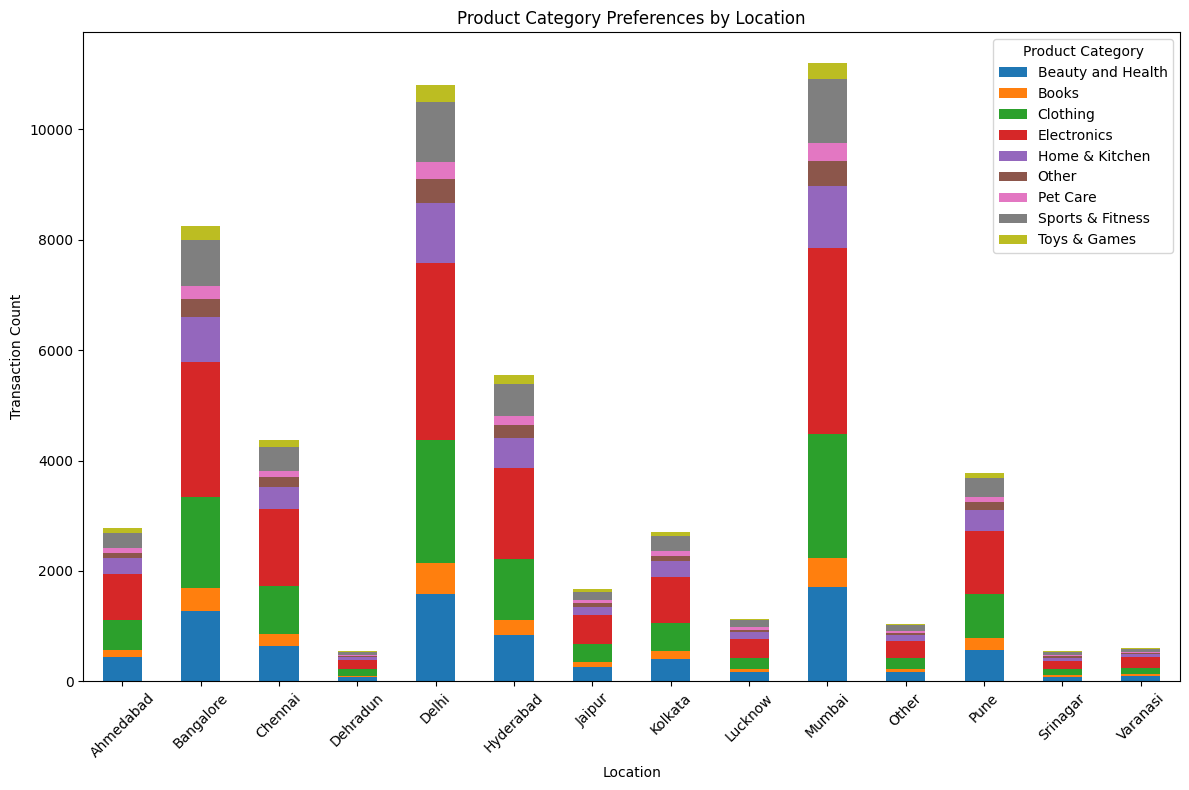

In [24]:
# Group by Location and Product Category
location_category_group = data.groupby(['Location', 'Product Category'], observed=True).size().reset_index(name='Transaction Count')

# Pivot the data for plotting
pivot_location_category = location_category_group.pivot(index='Location', columns='Product Category', values='Transaction Count').fillna(0)

# Plot a stacked bar chart
pivot_location_category.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.xlabel('Location')
plt.ylabel('Transaction Count')
plt.title('Product Category Preferences by Location')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()


High Transaction Locations:
-  Delhi, Mumbai, and Bangalore have the highest transaction counts, with Delhi being the highest overall, reaching around 12,000 transactions.
-  Mumbai follows closely with a similarly high number of transactions.
-  Bangalore shows a significant transaction count as well, but it is notably lower than Delhi and Mumbai.

Product Category Preferences by Location:

-  Clothing (represented in red) is a dominant product category across nearly all locations. It has a particularly strong presence in Delhi, Mumbai, and Bangalore.
-  Electronics (green) is another major category, contributing significantly in cities like Delhi, Mumbai, and Hyderabad.
-  Beauty and Health (blue) appears consistently across all locations but contributes more significantly in cities like Mumbai and Ahmedabad.

Smaller Locations:

-  Cities like Dehradun, Srinagar, and Varanasi have significantly fewer transactions compared to the larger cities. These locations show less diversity in product categories, with only a few categories contributing to their totals.

# 11. Time Series Analysis

## Monthly Sales Patterns

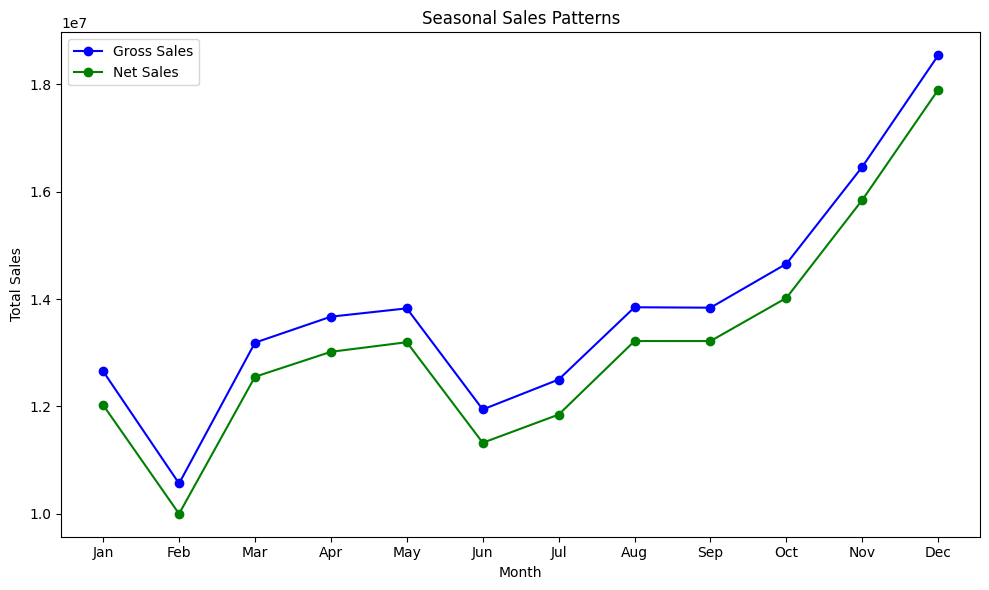

In [25]:
# Extract Month and Year from 'Purchase Date'
data['Month'] = data['Purchase Date'].dt.month
data['Year'] = data['Purchase Date'].dt.year

# Group by Month to calculate total sales
seasonal_sales_group = data.groupby('Month').agg({
    'Gross Amount': 'sum',
    'Net Amount': 'sum'
}).reset_index()

# Plot total gross and net sales by month
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(seasonal_sales_group['Month'], seasonal_sales_group['Gross Amount'], label='Gross Sales', marker='o', color='blue')
ax.plot(seasonal_sales_group['Month'], seasonal_sales_group['Net Amount'], label='Net Sales', marker='o', color='green')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
ax.set_title('Seasonal Sales Patterns')
ax.set_xticks(seasonal_sales_group['Month'])
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend()
plt.tight_layout()
plt.show()


-  Both Gross Sales (blue) and Net Sales (green) show a significant upward trend starting in October and peaking in December.
-  December has the highest sales volume, indicating a potential holiday season effect.

Mid-Year Decline:

-  There is a notable dip in both Gross and Net Sales during June and July, suggesting a potential seasonal slowdown during the summer months.

Sales Recovery After Early Year Dip:

-  After a drop in sales during February, sales begin to recover in March and stabilize through the spring months of April and May.

## Monthly Sales by Years

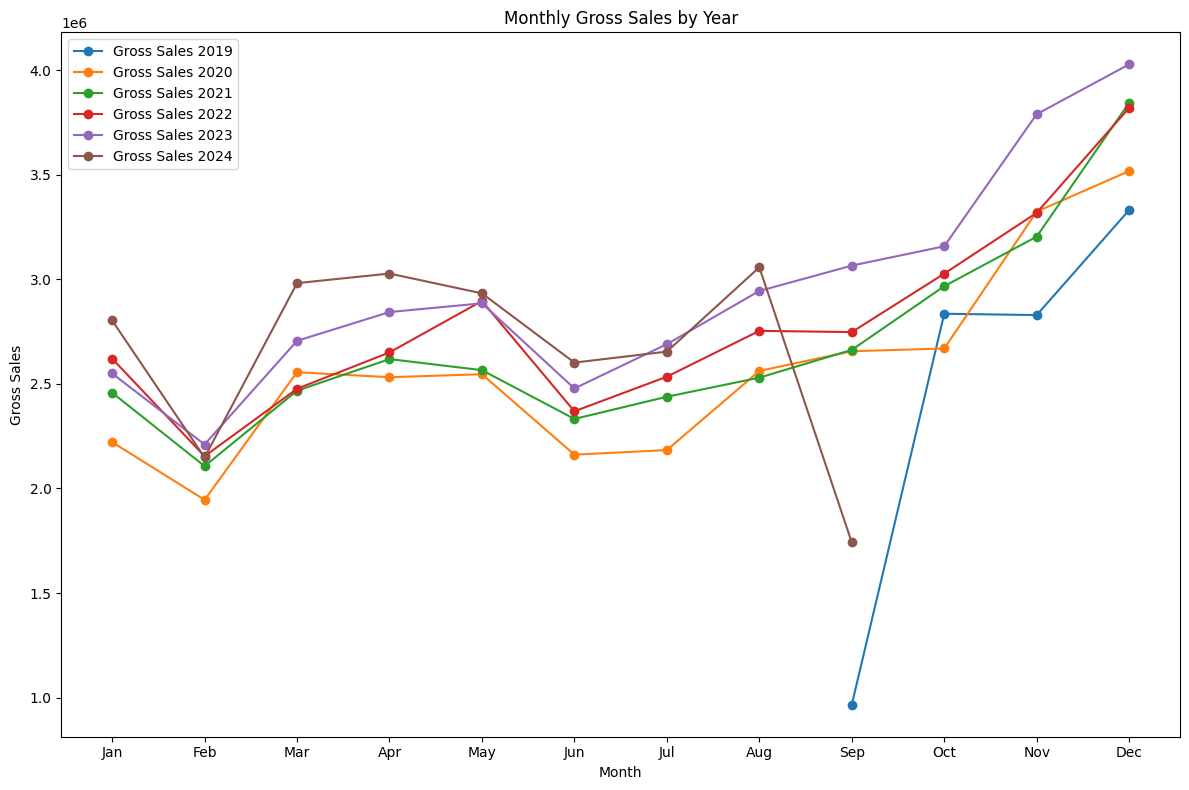

In [26]:
# Group by Year and Month
monthly_sales_by_year = data.groupby(['Year', 'Month']).agg({
    'Gross Amount': 'sum'
}).reset_index()

# Plot monthly sales for each year
fig, ax = plt.subplots(figsize=(12, 8))
for year in monthly_sales_by_year['Year'].unique():
    yearly_data = monthly_sales_by_year[monthly_sales_by_year['Year'] == year]
    ax.plot(yearly_data['Month'], yearly_data['Gross Amount'], label=f'Gross Sales {year}', marker='o')

ax.set_xlabel('Month')
ax.set_ylabel('Gross Sales')
ax.set_title('Monthly Gross Sales by Year')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend()
plt.tight_layout()
plt.show()


-  2020 has noticeably lower gross sales compared to other years, likely due to external factors (e.g., the pandemic), showing a more significant dip between March and April.
-  The sales recovery is slower in 2020 compared to other years.

-  2024 shows a sharp and unexpected drop in gross sales in September, which deviates from the trend observed in other years where sales usually recover after the summer dip.
-  Despite this, 2024 still ends the year with the highest gross sales in December.

-  2023 shows relatively steady growth, maintaining strong sales throughout the year, and performs well compared to earlier years, particularly in the second half of the year.

-  The sales trends for 2022 and 2021 follow a very similar pattern, with consistent growth after June and similar peaks in the final quarter of the year.

## Yearly Gross and Net Sales

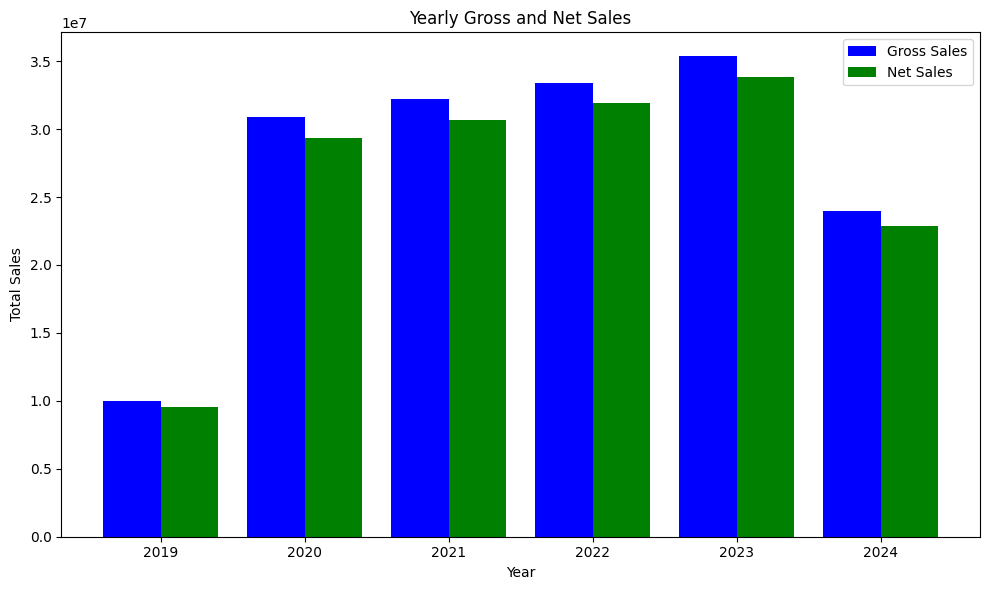

In [27]:
# Group by Year
yearly_sales = data.groupby('Year').agg({
    'Gross Amount': 'sum',
    'Net Amount': 'sum'
}).reset_index()

# Plot yearly gross and net sales
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(yearly_sales['Year'] - 0.2, yearly_sales['Gross Amount'], width=0.4, label='Gross Sales', color='blue')
ax.bar(yearly_sales['Year'] + 0.2, yearly_sales['Net Amount'], width=0.4, label='Net Sales', color='green')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales')
ax.set_title('Yearly Gross and Net Sales')
ax.legend()
plt.tight_layout()
plt.show()


Steady Increase in Sales from 2019 to 2023:

-  Both Gross Sales (blue) and Net Sales (green) show a steady increase from 2019 to 2023.
-  The highest gross and net sales are observed in 2023, reaching around 35 million in gross sales.

2020 to 2021 Growth:

-  There is a noticeable jump in both Gross and Net Sales between 2019 and 2020, with gross sales nearly tripling from around 10 million to 30 million.


## Yearly Gross Sales by Product Category

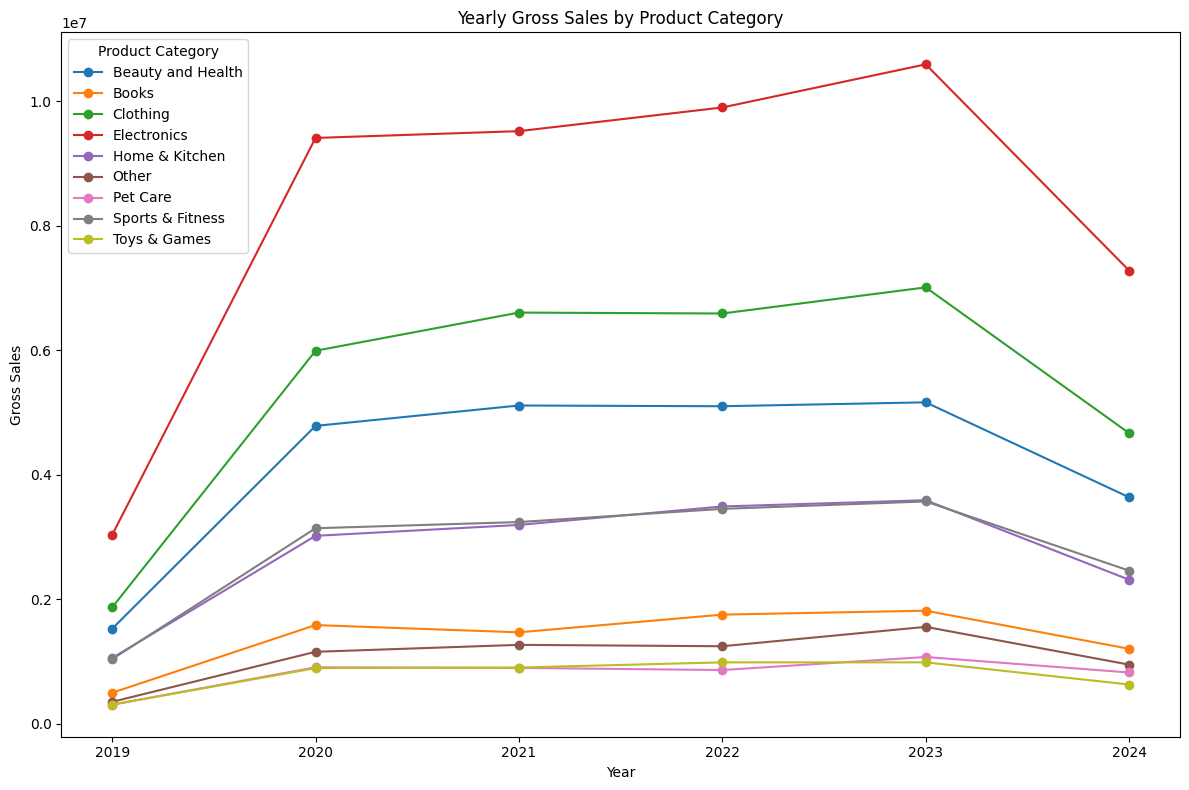

In [28]:
# Group by Product Category and Year
category_yearly_sales = data.groupby(['Product Category', 'Year'], observed=True).agg({
    'Gross Amount': 'sum'
}).reset_index()

# Plot gross sales for each product category over the years
fig, ax = plt.subplots(figsize=(12, 8))
for category in category_yearly_sales['Product Category'].unique():
    category_data = category_yearly_sales[category_yearly_sales['Product Category'] == category]
    ax.plot(category_data['Year'], category_data['Gross Amount'], label=category, marker='o')

ax.set_xlabel('Year')
ax.set_ylabel('Gross Sales')
ax.set_title('Yearly Gross Sales by Product Category')
ax.legend(title='Product Category')
plt.tight_layout()
plt.show()


Clothing (Red Line) as the Leading Category:

-  Clothing consistently dominates gross sales across all years, peaking in 2023 and then dropping significantly in 2024.
-  The category shows a steady rise from 2019 to 2022, maintaining its position as the top-selling category.

Electronics (Green Line) in Second Place:
-  Electronics shows strong and consistent growth from 2019 to 2022, followed by a slight decline in 2023 and a more significant drop in 2024.
-  It remains the second-largest contributor to gross sales after Clothing.

Low-Performing Categories:
-  Books, Toys & Games, and Pet Care consistently show the lowest gross sales across all years.
-  These categories have minimal growth and remain steady, contributing a small fraction of the overall gross sales.

## Total Sales and Transaction Count by Season

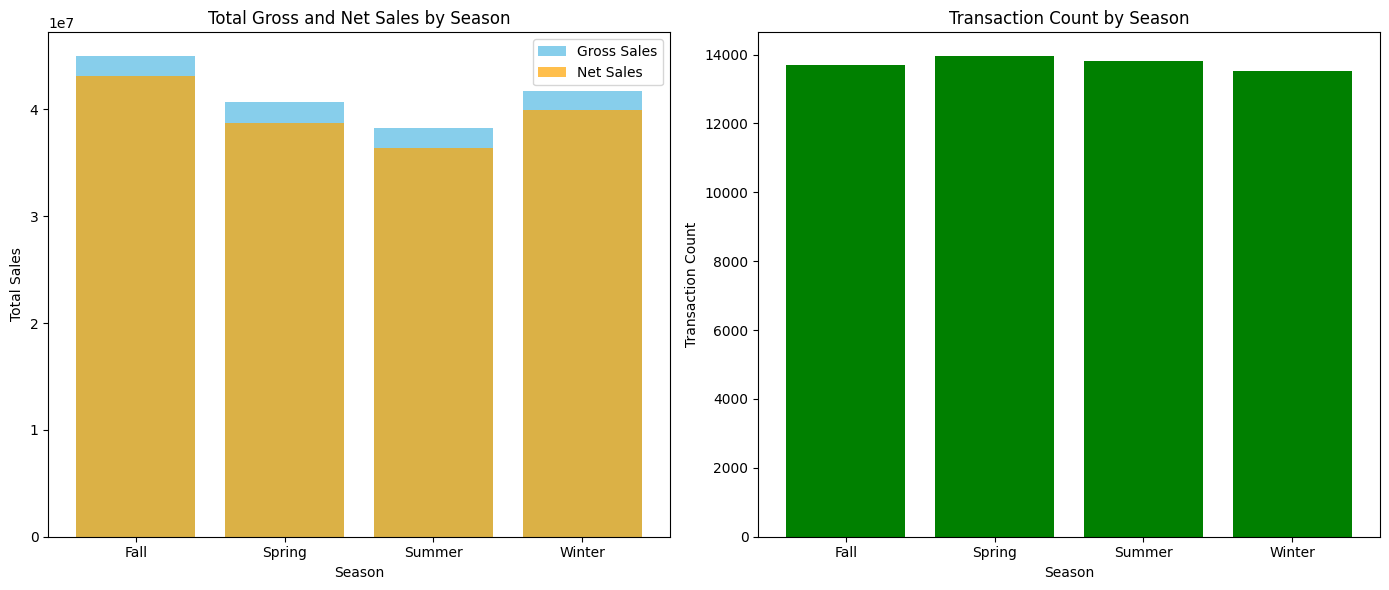

In [29]:
# Group by Purchase Season to calculate total sales and transaction count
seasonality_sales = data.groupby('Purchase Season', observed=True).agg({
    'Gross Amount': 'sum',
    'Net Amount': 'sum',
    'TID': 'count'  # TID is used to count transactions
}).reset_index()

# Rename columns for clarity
seasonality_sales.rename(columns={'TID': 'Transaction Count'}, inplace=True)

# Plot the seasonality effect on Gross and Net Sales
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot Gross and Net Sales
ax[0].bar(seasonality_sales['Purchase Season'], seasonality_sales['Gross Amount'], label='Gross Sales', color='skyblue')
ax[0].bar(seasonality_sales['Purchase Season'], seasonality_sales['Net Amount'], label='Net Sales', color='orange', alpha=0.7)
ax[0].set_xlabel('Season')
ax[0].set_ylabel('Total Sales')
ax[0].set_title('Total Gross and Net Sales by Season')
ax[0].legend()

# Plot Transaction Count
ax[1].bar(seasonality_sales['Purchase Season'], seasonality_sales['Transaction Count'], color='green')
ax[1].set_xlabel('Season')
ax[1].set_ylabel('Transaction Count')
ax[1].set_title('Transaction Count by Season')

plt.tight_layout()
plt.show()


Gross and Net Sales by Season (Left Plot):
-  Fall has the highest total Gross Sales and Net Sales, closely followed by Winter.
-  Summer has the lowest total gross and net sales, indicating a potential seasonal slowdown during the summer months.

Transaction Count by Season (Right Plot):
-  The transaction count is fairly consistent across all seasons, with Fall and Spring having slightly higher transaction volumes compared to Summer and Winter.

## Seasonality Effect by Product Category

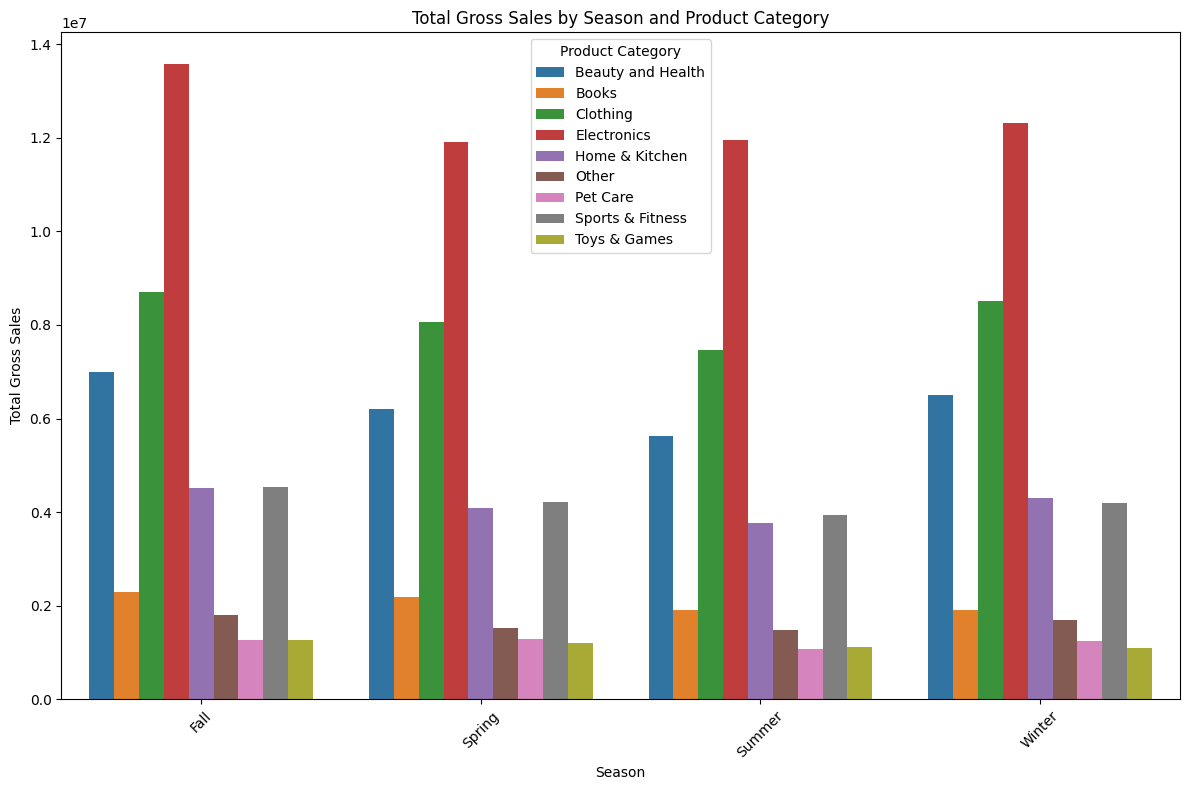

In [30]:
import seaborn as sns

# Group by Purchase Season and Product Category to calculate total sales
season_category_sales = data.groupby(['Purchase Season', 'Product Category'], observed=True).agg({
    'Gross Amount': 'sum',
    'Net Amount': 'sum',
    'TID': 'count'  # Transaction count
}).reset_index()

# Rename columns for clarity
season_category_sales.rename(columns={'TID': 'Transaction Count'}, inplace=True)

# Plot the seasonality effect by category for Gross Sales
plt.figure(figsize=(12, 8))
sns.barplot(x='Purchase Season', y='Gross Amount', hue='Product Category', data=season_category_sales)
plt.title('Total Gross Sales by Season and Product Category')
plt.ylabel('Total Gross Sales')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


-  Clothing (represented in red) consistently has the highest gross sales in every season. Its sales are particularly strong in Fall and Winter, peaking in Fall with over 1.3 million in gross sales.

-  Electronics (green) is the second-largest category in gross sales across all seasons, with a slight dip during Summer.

-  Toys & Games (yellow) has the lowest sales across all categories and remains relatively flat across seasons.

# 12. Purchase Method Analysis

## Total Sales by Purchase Method

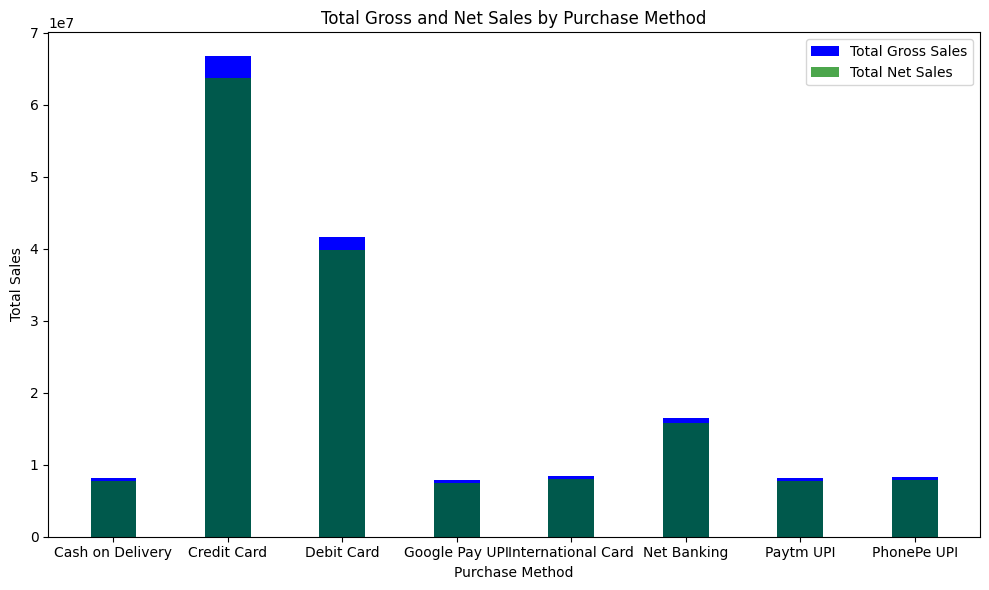

In [31]:
# Group by Purchase Method
purchase_method_sales = data.groupby('Purchase Method', observed=True).agg({
    'Gross Amount': ['sum', 'mean'],
    'Net Amount': ['sum', 'mean']
}).reset_index()

# Rename columns for clarity
purchase_method_sales.columns = ['Purchase Method', 'Total Gross Sales', 'Avg Gross Sales', 'Total Net Sales', 'Avg Net Sales']

# Plot total gross and net sales by purchase method
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(purchase_method_sales['Purchase Method'], purchase_method_sales['Total Gross Sales'], width=0.4, label='Total Gross Sales', color='blue')
ax.bar(purchase_method_sales['Purchase Method'], purchase_method_sales['Total Net Sales'], width=0.4, label='Total Net Sales', color='green', alpha=0.7)
ax.set_xlabel('Purchase Method')
ax.set_ylabel('Total Sales')
ax.set_title('Total Gross and Net Sales by Purchase Method')
ax.legend()
plt.tight_layout()
plt.show()


-  Credit Card is the most popular purchase method by a large margin, contributing approximately 70 million in gross sales.

-  Debit Card is the second-largest contributor to both gross and net sales, with gross sales just over 40 million.

-  Payment methods like Google Pay UPI, Paytm UPI, and PhonePe UPI contribute similar sales, but their overall contribution to gross sales is relatively low compared to traditional card-based payments.

## Transactions by Purchase Method and Location:

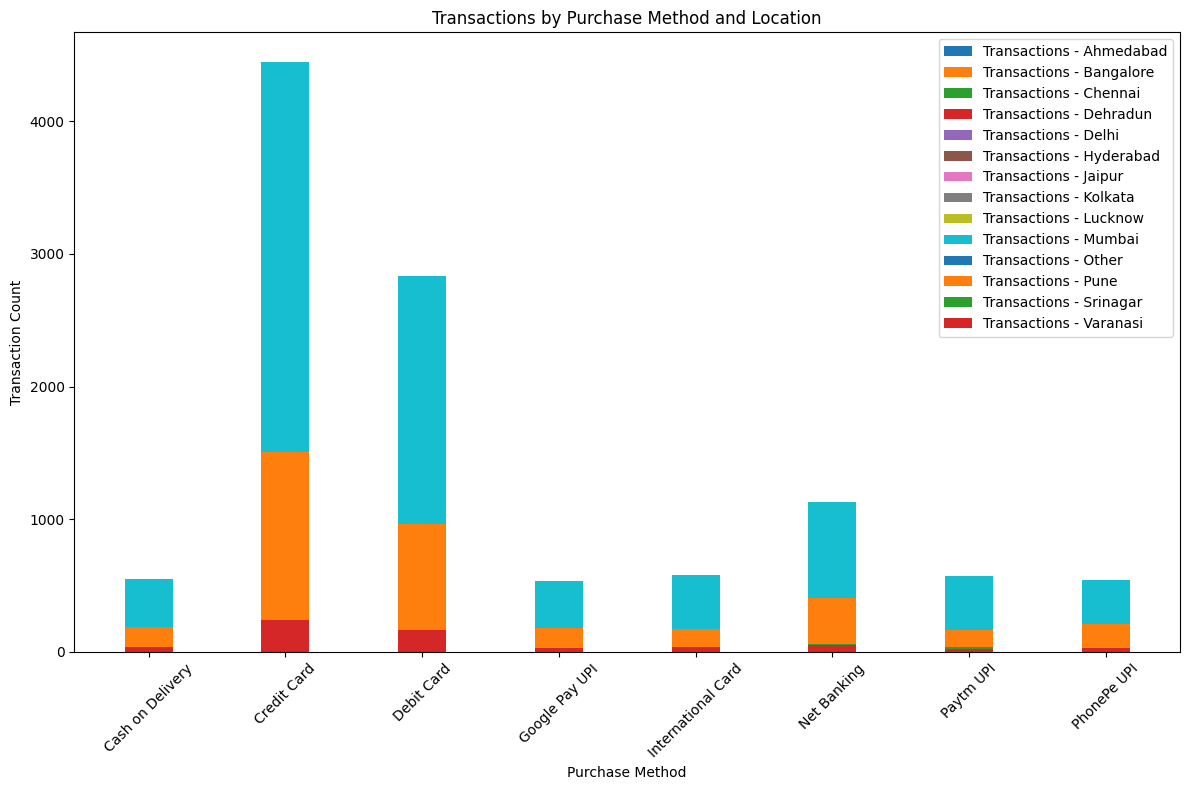

In [32]:
# Group by Purchase Method and Location to get the count of transactions
purchase_method_location_count = data.groupby(['Purchase Method', 'Location'], observed=True).size().reset_index(name='Transaction Count')

# Plot total transactions by purchase method and location
fig, ax = plt.subplots(figsize=(12, 8))

# Plotting by grouping location and purchase method
for location in purchase_method_location_count['Location'].unique():
    location_data = purchase_method_location_count[purchase_method_location_count['Location'] == location]
    
    ax.bar(location_data['Purchase Method'], location_data['Transaction Count'], width=0.35, label=f'Transactions - {location}')

# Set labels and titles
ax.set_xlabel('Purchase Method')
ax.set_ylabel('Transaction Count')
ax.set_title('Transactions by Purchase Method and Location')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


-  Credit Card transactions far exceed other payment methods, with over 4,000 transactions. The highest concentration of Credit Card transactions comes from Delhi (represented in blue), followed by other cities like Mumbai and Bangalore.

-  Debit Card follows Credit Card in transaction count, though it has significantly fewer transactions.

-  Delhi is the leading location in terms of transaction count for most payment methods, particularly Credit Card, Debit Card, and Net Banking.
-  Other locations like Mumbai, Bangalore, and Lucknow have noticeable but smaller contributions across several payment methods.

# 13. Customer Segmentation

## Customer Loyalty Analysis 

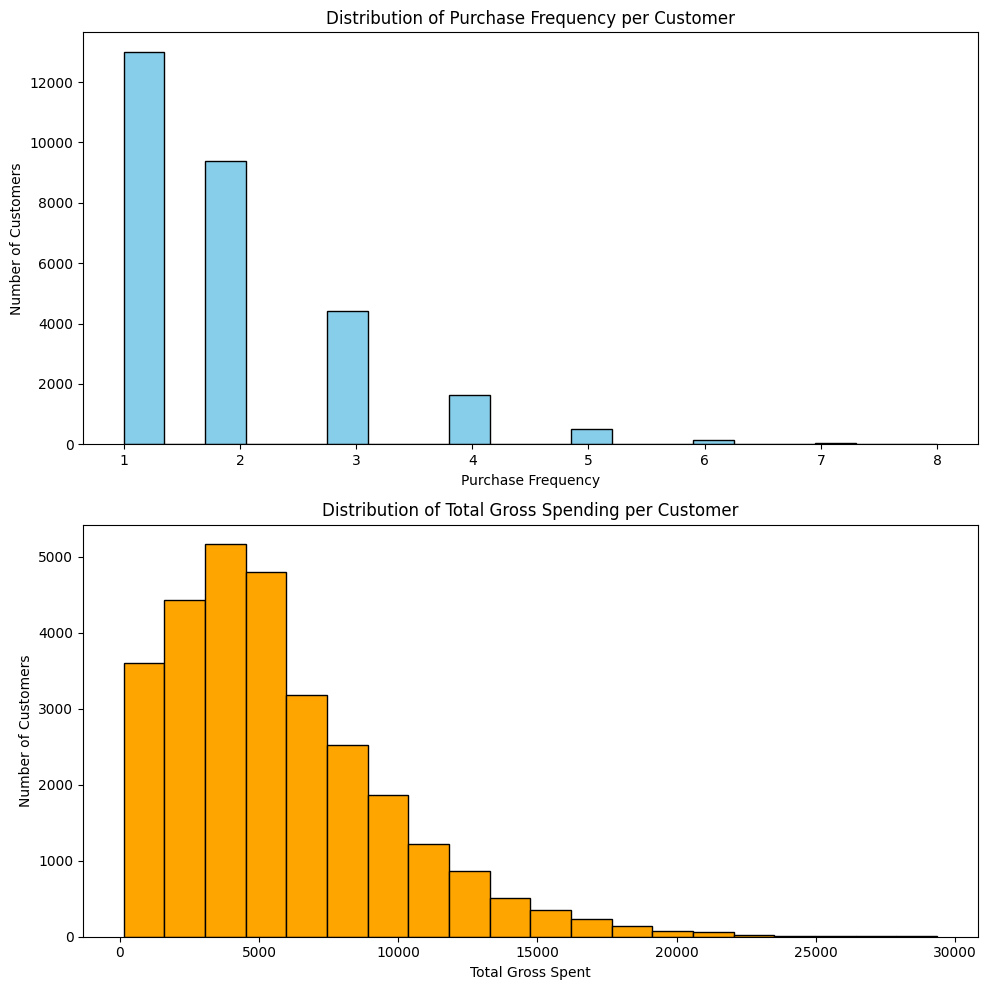

In [33]:
# Group by CID to calculate purchase frequency and spending
customer_loyalty = data.groupby('CID', observed=True).agg({
    'TID': 'count',
    'Gross Amount': 'sum',
    'Net Amount': 'sum',
}).reset_index()

customer_loyalty.columns = ['CID', 'Purchase Frequency', 'Total Gross Spent', 'Total Net Spent']

# Visualize Purchase Frequency and Total Gross Spending
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# Purchase Frequency Distribution
ax[0].hist(customer_loyalty['Purchase Frequency'], bins=20, color='skyblue', edgecolor='black')
ax[0].set_title('Distribution of Purchase Frequency per Customer')
ax[0].set_xlabel('Purchase Frequency')
ax[0].set_ylabel('Number of Customers')

# Total Gross Spending Distribution
ax[1].hist(customer_loyalty['Total Gross Spent'], bins=20, color='orange', edgecolor='black')
ax[1].set_title('Distribution of Total Gross Spending per Customer')
ax[1].set_xlabel('Total Gross Spent')
ax[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()


Purchase Frequency per Customer (Top Plot):
-  The majority of customers made only 1 purchase, with over 12,000 customers falling into this category.
-  As the number of purchases increases, the number of customers decreases sharply. Only a small portion of customers made 3 or more purchases.

Total Gross Spending per Customer (Bottom Plot):
-  Most customers spent relatively low amounts, with the highest number of customers spending between 2,500 and 5,000 units.
-  The distribution has a long tail, with a small number of customers spending more than 10,000 and very few spending over 20,000.

## Top Spending Customers by Product Category

In [34]:
# Group by CID and Product Category to calculate total spending
customer_category_spending = data.groupby(['CID', 'Product Category'], observed=True).agg({
    'Gross Amount': 'sum'
}).reset_index()

# Identify top spending customers in each category
top_spending_customers = customer_category_spending.sort_values(['Product Category', 'Gross Amount'], ascending=[True, False])

# Get the top 5 customers for each category
top_5_customers_by_category = top_spending_customers.groupby('Product Category', observed=True).head(5)

# Display the top 5 customers for each category
print("Top 5 Customers by Product Category:")
print(top_5_customers_by_category)


Top 5 Customers by Product Category:
          CID   Product Category  Gross Amount
3502   166071  Beauty and Health  15476.722550
41125  864366  Beauty and Health  14645.369900
4145   177794  Beauty and Health  14430.759600
35857  766542  Beauty and Health  14171.477600
1274   124173  Beauty and Health  13462.859950
7793   244121              Books  10945.408275
42944  898025              Books  10392.062250
48491  999507              Books  10247.650800
11875  319553              Books  10244.672800
26382  589554              Books   9941.603100
13008  340206           Clothing  18421.250050
27934  618927           Clothing  17353.185100
4825   189870           Clothing  16644.097200
42114  882257           Clothing  16263.983200
10634  295440           Clothing  16092.875700
23783  541042        Electronics  20066.153950
42167  883149        Electronics  19274.753100
5121   195280        Electronics  19220.645200
12974  339464        Electronics  17891.095800
9971   283919        El

-  Beauty and Health:

The top customer (CID: 166071) spent 15,476 on Beauty and Health products.
The other four top customers in this category spent between 13,462 and 14,754 units.

-  Books:

The top customer for Books (CID: 244121) spent 10,945.
The top 5 customers in this category spent between 9,941 and 10,945 units, showing a more consistent spending pattern.

-  Clothing:

The top customer in the Clothing category (CID: 340206) spent 18,421, which is significantly higher than the next four top customers, who spent between 16,029 and 17,353 units.

-  Electronics:

The top customer for Electronics (CID: 541048) spent 20,066, the highest among all categories in this dataset.
Other top customers spent between 17,586 and 19,224 units, showing that Electronics has some high-spending customers.



# 14. Business Recommendations

**Customer Retention:** 
Focus on strategies to increase purchase frequency among customers, such as loyalty programs or personalized offers. Encouraging repeat purchases could significantly boost sales.

**Target High-Value Customers:** High-spending customers in categories like Electronics, Clothing, and Beauty and Health are key contributors to revenue.

**Seasonal Promotions:** Summer shows a dip in sales, so introducing promotional campaigns during this period could help smooth out the seasonal fluctuations. Fall and Winter are already strong sales periods, so leveraging this with holiday promotions and product bundling can further maximize revenue

**Location-Specific Marketing:** Focus marketing efforts on top-performing cities like Delhi, Mumbai, and Bangalore, where the majority of transactions take place.

# 15. conclution

This project analyzed customer transaction data to uncover purchasing behaviors, product preferences, sales trends, and customer demographics through data preprocessing, validation, feature engineering, and exploratory data analysis.

## Customer Behavior

* Most customers made only one or two purchases, with a significant decline in repeat purchases, indicating opportunities to improve customer retention.
* Purchasing patterns were generally consistent across different demographic groups, with no substantial differences observed between genders.

## Product Performance

* **Clothing** was the highest-performing product category across multiple metrics, including gross sales, customer spending, and seasonal demand.
* **Electronics** and **Beauty & Health** also generated strong sales and attracted high-spending customers.
* Categories such as **Books**, **Pet Care**, and **Toys & Games** contributed comparatively less to overall revenue.

## Seasonal Trends

* **Fall** and **Winter** recorded the highest sales volumes, primarily driven by increased demand for Clothing and Electronics.
* Sales declined during the **Summer** season, suggesting opportunities for seasonal marketing campaigns.

## Payment Methods

* **Credit Cards** were the preferred payment method, generating the highest gross and net sales.
* **Debit Cards** ranked second, while **Net Banking** also accounted for a notable share of transactions.
* Digital payment methods, including **Google Pay**, **Paytm**, and **PhonePe**, were used less frequently than traditional card-based payments.

## Geographic Insights

* **Delhi**, **Mumbai**, and **Bangalore** were the leading locations in terms of transaction volume and sales, highlighting them as key markets.

Overall, the analysis demonstrates how exploratory data analysis can reveal actionable business insights from transactional data. The cleaned and validated dataset provides a strong foundation for future predictive analytics, customer segmentation, and machine learning applications.
